In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the space-separated file
df = pd.read_csv("cal_housing.data", header=None, sep=",")

In [4]:
#Get the columns from the file
df.columns = [
    "longitude", 
    "latitude", 
    "housingMedianAge", 
    "totalRooms", 
    "totalBedrooms", 
    "population", 
    "households", 
    "medianIncome", 
    "medianHouseValue"
]

In [5]:
df.head()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [6]:
df.dtypes

longitude           float64
latitude            float64
housingMedianAge    float64
totalRooms          float64
totalBedrooms       float64
population          float64
households          float64
medianIncome        float64
medianHouseValue    float64
dtype: object

In [7]:
# Print the unique values and the number of non-unique values
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

longitude
[-122.23 -122.22 -122.24 -122.25 -122.26]
844

latitude
[37.88 37.86 37.85 37.84 37.83]
862

housingMedianAge
[41. 21. 52. 42. 50.]
52

totalRooms
[ 880. 7099. 1467. 1274. 1627.]
5926

totalBedrooms
[ 129. 1106.  190.  235.  280.]
1928

population
[ 322. 2401.  496.  558.  565.]
3888

households
[ 126. 1138.  177.  219.  259.]
1815

medianIncome
[8.3252 8.3014 7.2574 5.6431 3.8462]
12928

medianHouseValue
[452600. 358500. 352100. 341300. 342200.]
3842



<Axes: xlabel='medianHouseValue', ylabel='Count'>

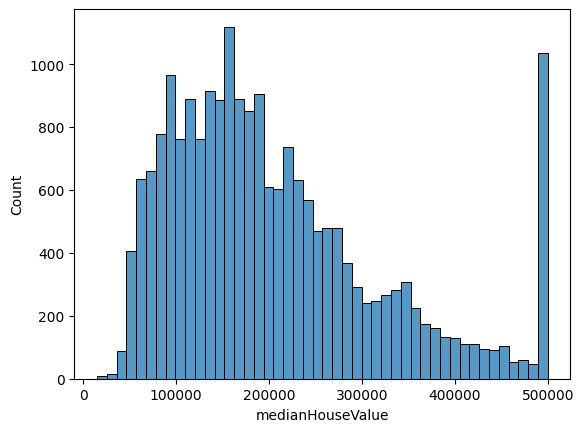

In [8]:
# medianHouseValue is the target variable, so that’s the housing price to predict
sns.histplot(df.medianHouseValue)

In [9]:
df.shape[0]

20640

#### medianHouseValue has a right tail since most homes are affordable, but a few extremely expensive ones pull the distribution far to the right.

In [10]:
# log1p compresses large values i.e (shrinks the tail)
# Keeps the scale of small values relatively intact
# Helps make the distribution more normal-shaped (Gaussian)

house_value_logs = np.log1p(df.medianHouseValue)

In [11]:
house_value_logs

0        13.022766
1        12.789687
2        12.771673
3        12.740520
4        12.743154
           ...    
20635    11.265758
20636    11.252872
20637    11.432810
20638    11.346883
20639    11.400887
Name: medianHouseValue, Length: 20640, dtype: float64

<Axes: xlabel='medianHouseValue', ylabel='Count'>

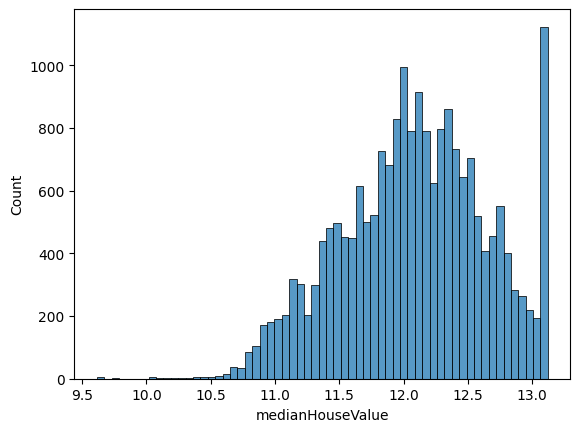

In [12]:
sns.histplot(house_value_logs)

In [13]:
# Values above $500,001 were censored, which may bias predictions for high-value homes.
df_capped = (df["medianHouseValue"] > 500000).sum()

In [14]:
df_capped

np.int64(965)

# Setting up the validation framework

In [15]:
np.random.seed(2)

n = len(df)

# split dataset where 20% is the validation and test data, while 60% is the train data
n_val = int(0.2 * n) 
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

In [16]:
n_val, n_test, n_train

(4128, 4128, 12384)

In [17]:
# We need to shuffle the dataset before splitting, so we don't have the split in a sequential order
idx = np.arange(n)
np.random.shuffle(idx)
print('idx here', idx)
df_shuffled = df.iloc[idx]

idx here [10385  1943  7490 ... 11798  6637  2575]


In [18]:
# Here we split, we use the copy() so we can still keep the original dataset
df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [19]:
# We reset the index in a sequential order
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [20]:
df_train.head()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
0,-117.65,33.60,15.0,5736.0,800.0,2529.0,762.0,6.4114,278700.0
1,-120.91,38.62,12.0,4545.0,748.0,2033.0,718.0,4.1843,207600.0
2,-118.23,33.93,35.0,1149.0,277.0,909.0,214.0,1.7411,96700.0
3,-122.37,37.59,39.0,4645.0,1196.0,2156.0,1113.0,3.4412,353800.0
4,-117.98,33.70,16.0,5127.0,631.0,2142.0,596.0,7.8195,390500.0


In [21]:
# To reduce skewness and stabilize variance, log1p is applied, making the regression model perform better.
y_train = np.log1p(df_train['medianHouseValue'].values)
y_val = np.log1p(df_val['medianHouseValue'].values)
y_test = np.log1p(df_test['medianHouseValue'].values)

In [22]:
del df_train['medianHouseValue']
del df_val['medianHouseValue']
del df_test['medianHouseValue']

In [23]:
df_train.head()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome
0,-117.65,33.60,15.0,5736.0,800.0,2529.0,762.0,6.4114
1,-120.91,38.62,12.0,4545.0,748.0,2033.0,718.0,4.1843
2,-118.23,33.93,35.0,1149.0,277.0,909.0,214.0,1.7411
3,-122.37,37.59,39.0,4645.0,1196.0,2156.0,1113.0,3.4412
4,-117.98,33.70,16.0,5127.0,631.0,2142.0,596.0,7.8195


In [24]:
len(y_train)

12384

# Linear regression

In [25]:
df_train.iloc[10] # Show me the 11th row of the df_train

longitude           -117.9900
latitude              33.6600
housingMedianAge      14.0000
totalRooms          3155.0000
totalBedrooms        653.0000
population           951.0000
households           575.0000
medianIncome           3.0625
Name: 10, dtype: float64

In [26]:
# manual implementation of linear regression using NumPy and linear algebra (without using scikit-learn)
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X) # X.T = transpose of X
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

# Baseline model

In [27]:
df_train.columns

Index(['longitude', 'latitude', 'housingMedianAge', 'totalRooms',
       'totalBedrooms', 'population', 'households', 'medianIncome'],
      dtype='object')

In [28]:
# These are the independent variables (X) we’ll use to predict the dependent variable (y)
base = ['totalRooms', 'totalBedrooms', 'households',
        'medianIncome', 'population']

In [29]:
# .fillna(0) replaces any missing values with 0 (so the math won’t break)
# .values converts the DataFrame into a NumPy array — because your function train_linear_regression() expects numerical arrays, not Pandas objects.

X_train = df_train[base].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

In [30]:
w

array([-1.32357362e-04,  3.46860146e-04,  8.37779061e-04,  2.22109963e-01,
       -1.43613053e-04])

<Axes: ylabel='Count'>

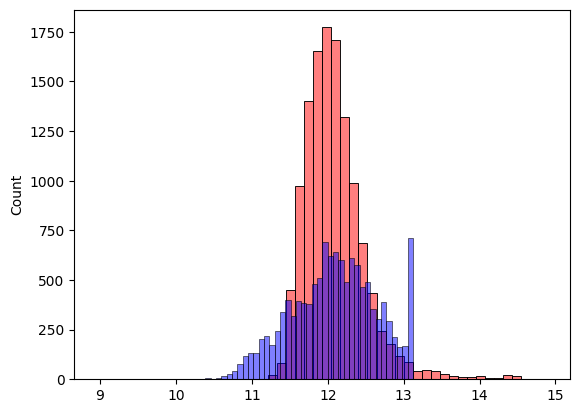

In [31]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

##### Overall overlap — good sign

##### The red (predicted) and blue (actual) histograms overlap quite a bit in the center (around 11.5–12.5).

##### This means your model has captured the general shape and central tendency of the housing values quite well.

# Root Mean Squared Error(RMSE)

In [32]:
# RMSE measures how far your predictions are from the true values, on average
# Smaller RMSE → better model
# Because it means your predictions are closer to actual values

def rmse(y, y_pred):
    se = (y - y_pred) ** 2 # squared errors
    mse = se.mean() # mean squared error
    return np.sqrt(mse) # root mean squared error

In [33]:
float(rmse(y_train, y_pred))

0.4064908877325956

# Validating the model

In [34]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [35]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.40114854802847943)

# Simple feature engineering

In [36]:
def prepare_X(df):
    df = df.copy()

    # Tells you the average house size in the area.
    # High value → bigger homes, likely more expensive.
    df['rooms_per_household'] = df['totalRooms'] / df['households'] 

    # It captures “wealth density” — areas where income is high and people per household are few tend to have higher-value homes.
    df['population_per_household'] = df['population'] / df['households']
    df['income_per_person'] = df['medianIncome'] / df['population_per_household']

    # Captures the bedroom-to-room ratio → smaller values often indicate more spacious houses
    df['bedrooms_per_room'] = df['totalBedrooms'] / df['totalRooms']
    
    features = base + ['rooms_per_household', 'income_per_person', 'bedrooms_per_room']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X
    

In [37]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.384141790569247)

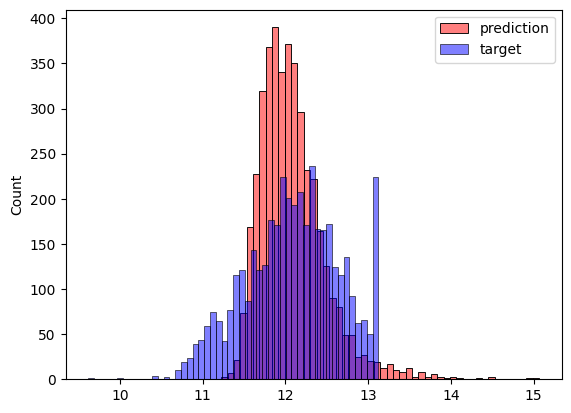

In [38]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()

###### DO THIS LATER: Would you like me to show you how to visualize which of your features have the strongest effect (e.g., using the learned coefficients w from your model)? That can help you interpret what the model “believes” drives house prices.

# Regularization

#### Regularization is a technique used to:
##### Prevent your model from overfitting the training data by discouraging it from learning overly large or complex weights.
##### Without regularization, your model might “memorize” the training data.
##### With regularization, it “learns general patterns” that work better on new, unseen data.

##### When to use regularization

###### - When you have many features (e.g., after adding ratios, interactions, or dummy variables).

###### - When you see a large gap between training accuracy and validation accuracy (overfitting).

###### - When your model weights are large or unstable.

In [39]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [40]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.00001)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.384141790233615)

# Tuning the model

In [41]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(r, w0, score)

0.0 10.69735027941651 0.384141790569247
1e-05 10.697349987538086 0.384141790233615
0.0001 10.697347360624528 0.3841417872130009
0.001 10.697321092712693 0.3841417570236394
0.1 10.694444740113777 0.38413861930799426
1 10.669406530046135 0.3841258658415014
10 10.482501124928644 0.38514278068831614


# Using the model

In [43]:
df_full_train = pd.concat([df_train, df_val])

In [44]:
df_full_train = df_full_train.reset_index(drop=True)

In [45]:
X_full_train = prepare_X(df_full_train)

In [46]:
X_full_train

array([[5.73600000e+03, 8.00000000e+02, 7.62000000e+02, ...,
        7.52755906e+00, 1.93178600e+00, 1.39470014e-01],
       [4.54500000e+03, 7.48000000e+02, 7.18000000e+02, ...,
        6.33008357e+00, 1.47778032e+00, 1.64576458e-01],
       [1.14900000e+03, 2.77000000e+02, 2.14000000e+02, ...,
        5.36915888e+00, 4.09895930e-01, 2.41079199e-01],
       ...,
       [2.47900000e+03, 3.90000000e+02, 3.63000000e+02, ...,
        6.82920110e+00, 1.38222896e+00, 1.57321501e-01],
       [1.86000000e+03, 4.00000000e+02, 3.65000000e+02, ...,
        5.09589041e+00, 4.90551011e-01, 2.15053763e-01],
       [4.92500000e+03, 9.48000000e+02, 8.94000000e+02, ...,
        5.50894855e+00, 1.79591526e+00, 1.92487310e-01]], shape=(16512, 8))

In [47]:
y_full_train = np.concatenate([y_train, y_val])

In [54]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)


In [55]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.39936046899849414)

In [56]:
house = df_test.iloc[20].to_dict()

In [57]:
house

{'longitude': -117.4,
 'latitude': 34.01,
 'housingMedianAge': 25.0,
 'totalRooms': 1858.0,
 'totalBedrooms': 366.0,
 'population': 1311.0,
 'households': 331.0,
 'medianIncome': 2.7083}

In [58]:
df_small = pd.DataFrame([house])
df_small

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome
0,-117.4,34.01,25.0,1858.0,366.0,1311.0,331.0,2.7083


In [59]:
X_small = prepare_X(df_small)

In [60]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(11.645910569859492)

In [61]:
np.expm1(y_pred)

np.float64(114222.29845173919)

In [62]:
np.expm1(y_test[20])

np.float64(87799.99999999994)